In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from aijack.collaborative.fedavg import FedAVGAPI, FedAVGClient, FedAVGServer
from aijack.attack.inversion import GradientInversionAttackServerManager


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_shape = (1, 28, 28) # MNIST shape
num_classes = 10

#BASELINE MODEL: LeNet with Sigmoid activations (more vulnerable than ReLU)
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        act = nn.Sigmoid 
        self.body = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=5, padding=2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=2),
            act(),
        )
        self.fc = nn.Sequential(nn.Linear(12 * 7 * 7, num_classes))

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)


transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

secret_x_cpu, secret_y_raw = dataset[7]
secret_x_cpu = secret_x_cpu.unsqueeze(0)  
secret_y_cpu = torch.tensor([secret_y_raw], dtype=torch.long)
secret_x = secret_x_cpu.to(device)


# Manager to turn the server into an attacker
manager = GradientInversionAttackServerManager(
    input_shape,
    device=device,
    num_iteration=100,
    lr=1.0,
    log_interval=20,
    optimizer_class=torch.optim.LBFGS,
    distancename="l2"
 )

AttackingServer = manager.attach(FedAVGServer)


base_model = LeNet().to(device)
client = FedAVGClient(copy.deepcopy(base_model), user_id=0, lr=0.1, device=device)
server = AttackingServer([client], copy.deepcopy(base_model), device=device)

#FL environment baseline (1 client)
criterion = nn.CrossEntropyLoss()
local_dataloaders = [DataLoader(TensorDataset(secret_x_cpu, secret_y_cpu), batch_size=1, shuffle=False)]
local_optimizers = [optim.SGD(client.parameters(), lr=client.lr)]

api = FedAVGAPI(
    server,
    [client],
    criterion,
    local_optimizers,
    local_dataloaders,
    num_communication=1,
    local_epoch=1,
    use_gradients=True,
    device=device,
 )

print("Starting Reconstruction Attack...")
api.run()
reconstructed_data, reconstructed_label = server.attack_results[0][0]

Starting Reconstruction Attack...
iter=20: 5.697717853081485e-09, (best_iter=5: 5.697717853081485e-09)
iter=40: 5.697717853081485e-09, (best_iter=5: 5.697717853081485e-09)
iter=56: loss did not improve in the last 50 rounds.


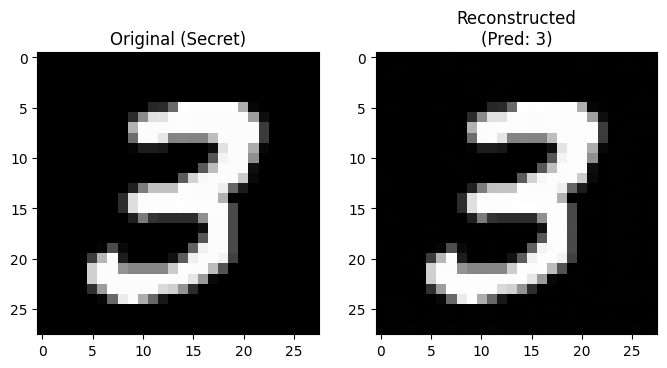

In [2]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original (Secret)")
plt.imshow(secret_x_cpu[0][0].detach().numpy(), cmap='gray')

plt.subplot(1, 2, 2)
if reconstructed_label.ndim == 0:
    pred_label = int(reconstructed_label.item())
elif reconstructed_label.ndim == 1:
    pred_label = int(torch.argmax(reconstructed_label).item())
else:
    pred_label = int(torch.argmax(reconstructed_label[0]).item())
plt.title(f"Reconstructed\n(Pred: {pred_label})")
plt.imshow(reconstructed_data[0][0].cpu().detach().numpy(), cmap='gray')
plt.show()